# Importy i dataset

In [ ]:
import os
import json
import random
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

In [3]:
class CVLDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("L")  # konwertujemy na grayscale
        if self.transform:
            img = self.transform(img)
        return img, label

# Podział danych na train i val

In [ ]:
import re
import json
import os
import random
from tqdm import tqdm

def split_by_author(
    root_dir,
    authors_json,
    val_split=0.2,
    seed=42,
    save_path="val_split_lines_27.json",
    stats_path="split_stats_lines_27.json",
    pages_path="split_pages_lines_27.json"   # NOWY PLIK: strony train/val
):
    random.seed(seed)

    with open(authors_json, "r") as f:
        author_to_id = json.load(f)

    # JEŚLI SPLIT JUŻ ISTNIEJE – WCZYTAJ
    if os.path.exists(save_path) and os.path.exists(pages_path):
        print(f" Wczytywanie istniejącego splitu z {save_path}")
        with open(save_path, "r") as f:
            split_data = json.load(f)

        train_samples = [tuple(s) for s in split_data["train"]]
        val_samples   = [tuple(s) for s in split_data["val"]]
        return train_samples, val_samples

    print(" Tworzenie nowego splitu stron i zapisywanie do plików...")

    train_samples, val_samples = [], []
    excluded_authors = []

    stats = {
        "per_author": {},
        "val_split": val_split,
        "seed": seed
    }

    pages_info = {}   # TU BĘDZIE: które strony do train, które do val

    filename_pattern = re.compile(r"^(.+)-(\d+)-(\d+)$")

    for author, label in tqdm(author_to_id.items(), desc="Przetwarzanie autorów"):
        author_path = os.path.join(root_dir, author)
        if not os.path.isdir(author_path):
            continue

        files = [
            f for f in os.listdir(author_path)
            if f.lower().endswith((".png", ".jpg", ".tif", ".tiff"))
        ]

        if len(files) == 0:
            excluded_authors.append(author)
            continue

        # --- GRUPOWANIE PO STRONACH ---
        pages = {}
        for filename in files:
            name_wo_ext, _ = os.path.splitext(filename)
            m = filename_pattern.match(name_wo_ext)
            if m is None:
                continue

            page_id = m.group(2)   # ID strony
            full_path = os.path.join(author_path, filename)
            pages.setdefault(page_id, []).append(full_path)

        num_pages = len(pages)
        num_files = sum(len(v) for v in pages.values())

        if num_pages < 2:
            excluded_authors.append(author)
            continue

        page_keys = list(pages.keys())
        random.shuffle(page_keys)

        split_idx = int(len(page_keys) * (1 - val_split))
        train_pages = page_keys[:split_idx]
        val_pages   = page_keys[split_idx:]

        train_count = 0
        val_count   = 0

        for p in train_pages:
            paths = pages[p]
            train_samples.extend([(path, label) for path in paths])
            train_count += len(paths)

        for p in val_pages:
            paths = pages[p]
            val_samples.extend([(path, label) for path in paths])
            val_count += len(paths)

        # ZAPIS STRON PER AUTOR
        pages_info[author] = {
            "label": label,
            "train_pages": train_pages,
            "val_pages": val_pages
        }

        # STATYSTYKI
        stats["per_author"][author] = {
            "label": label,
            "num_pages": num_pages,
            "num_files": num_files,
            "train_pages": len(train_pages),
            "val_pages": len(val_pages),
            "train_samples": train_count,
            "val_samples": val_count
        }

    print(f" Train samples: {len(train_samples)} | Val samples: {len(val_samples)}")
    print(f" Wykluczonych autorów: {len(excluded_authors)}")

    # ZAPIS SPLITU
    split_data = {
        "train": train_samples,
        "val": val_samples,
        "excluded_authors": excluded_authors
    }

    with open(save_path, "w") as f:
        json.dump(split_data, f, indent=2)

    with open(stats_path, "w") as f:
        json.dump(stats, f, indent=2)

    with open(pages_path, "w") as f:
        json.dump(pages_info, f, indent=2)

    print(f" Split zapisany do: {save_path}")
    print(f" Statystyki zapisane do: {stats_path}")
    print(f" Podział stron zapisany do: {pages_path}")

    return train_samples, val_samples


In [24]:
from collections import Counter

def print_split_overview(train_samples, val_samples):
    train_labels = [label for _, label in train_samples]
    val_labels   = [label for _, label in val_samples]

    train_counts = Counter(train_labels)
    val_counts   = Counter(val_labels)

    print("\n Rozkład liczby próbek na klasę (train):")
    for label, cnt in sorted(train_counts.items()):
        print(f"  Klasa {label}: {cnt} próbek")

    print("\n Rozkład liczby próbek na klasę (val):")
    for label, cnt in sorted(val_counts.items()):
        print(f"  Klasa {label}: {cnt} próbek")

    print("\n Podsumowanie:")
    print(f"  Liczba klas w train: {len(train_counts)}")
    print(f"  Liczba klas w val:   {len(val_counts)}")

# Transformacje 

In [13]:
def get_transforms():
    transform_train = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224, 224)),
        transforms.RandomRotation(5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.05,0.05), scale=(0.95,1.05)),
        transforms.GaussianBlur(3),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    transform_val = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    return transform_train, transform_val
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: mps


# Model ResNet-50

In [7]:
def build_model(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    return model.to(device)

# Funkcja treningu i ewaluacji

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    correct, total, total_loss = 0, 0, 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss/total, correct/total

def evaluate(model, loader, criterion):
    model.eval()
    correct, total, total_loss = 0, 0, 0.0
    all_labels, all_preds = [], []
    with torch.no_grad(): 
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    return total_loss/total, correct/total, all_labels, all_preds

# Funkcje wizualizacji i analiza autorów

In [8]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"])+1)
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss over Epochs")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy over Epochs")
    plt.legend()
    plt.show()

def plot_confusion(labels, preds, classes, title="Confusion Matrix"):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(xticks_rotation=90)
    plt.title(title)
    plt.show()

def author_difficulty(labels, preds, classes):
    cm = confusion_matrix(labels, preds)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    sorted_idx = np.argsort(per_class_acc)
    print("\nNajtrudniejsi autorzy:")
    for i in sorted_idx[:5]:
        print(f"{classes[i]} - Acc: {per_class_acc[i]:.4f}")
    print("\nNajłatwiejsi autorzy:")
    for i in sorted_idx[-5:]:
        print(f"{classes[i]} - Acc: {per_class_acc[i]:.4f}")
    return per_class_acc

# Trening modelu etapami

In [22]:
def train_model(root_dir, authors_json, stages, batch_size=16, save_path="best_model.pth"):
    
    # BEZPIECZNY, POWTARZALNY SPLIT
    train_samples, val_samples = split_by_author(
        root_dir,
        authors_json,
        val_split=0.2,
        seed=42,
        save_path="val_split_lines_27.json"
    )


    print_split_overview(train_samples, val_samples)

    # TRANSFORMACJE
    transform_train, transform_val = get_transforms()

    train_dataset = CVLDataset(train_samples, transform=transform_train)
    val_dataset   = CVLDataset(val_samples,   transform=transform_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

    num_classes = len(set(label for _, label in train_samples))
    print(f" Number of classes (authors): {num_classes}")

    # MODEL
    model = build_model(num_classes)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    # TRENING ETAPOWY
    for stage in stages:
        print(f"\n Stage: {stage['name']} | Epochs: {stage['epochs']} | LR={stage['lr']}")

        # Zamrażanie wszystkiego
        for param in model.parameters():
            param.requires_grad = False

        # Odmrażanie wybranych warstw
        if "all" in stage["unfreeze"]:
            for param in model.parameters():
                param.requires_grad = True
        else:
            for name, module in model.named_children():
                if name in stage["unfreeze"]:
                    for param in module.parameters():
                        param.requires_grad = True

        # FC zawsze uczymy
        for param in model.fc.parameters():
            param.requires_grad = True

        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=stage["lr"]
        )

        # EPOKI
        for epoch in range(stage["epochs"]):
            train_loss, train_acc = train_one_epoch(
                model, train_loader, optimizer, criterion
            )

            val_loss, val_acc, val_labels, val_preds = evaluate(
                model, val_loader, criterion
            )

            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)

            print(
                f"Epoch {epoch+1}/{stage['epochs']} | "
                f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}"
            )

            # ZAPIS NAJLEPSZEGO MODELU
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), save_path)
                print(f"Zapisano najlepszy model (val_acc={val_acc:.4f})")

    print(f"\n NAJLEPSZE VAL ACC: {best_val_acc:.4f}")
    return model, val_labels, val_preds, history

# Konfiguracja etapów i uruchomienie treningu

In [26]:
stages_27 = [
    {"name": "Layer4 only", "unfreeze": ["layer4"], "epochs": 10, "lr": 1e-4},
    {"name": "Layer3+Layer4", "unfreeze": ["layer3","layer4"], "epochs": 10, "lr": 5e-5},
    {"name": "Full fine-tune", "unfreeze": ["all"], "epochs": 5, "lr": 1e-5}
]

root_dir_27 = "/Users/maciekgrubek/Downloads/cvl-database-1-1/trainset/lines"
authors_json_27 = "/Users/maciekgrubek/PracaInzynierska/authors.json"

model_27, val_labels_27, val_preds_27, history_27 = train_model(
    root_dir_27, authors_json_27, stages=stages_27, save_path="best_model_lines.pth"
)

 Tworzenie nowego splitu stron i zapisywanie do plików...


Przetwarzanie autorów: 100%|██████████| 27/27 [00:00<00:00, 1517.19it/s]

 Train samples: 1146 | Val samples: 478
 Wykluczonych autorów: 0
 Split zapisany do: val_split_lines_27.json
 Statystyki zapisane do: split_stats_lines_27.json
 Podział stron zapisany do: split_pages_lines_27.json

 Rozkład liczby próbek na klasę (train):
  Klasa 0: 46 próbek
  Klasa 1: 39 próbek
  Klasa 2: 37 próbek
  Klasa 3: 45 próbek
  Klasa 4: 50 próbek
  Klasa 5: 41 próbek
  Klasa 6: 53 próbek
  Klasa 7: 43 próbek
  Klasa 8: 43 próbek
  Klasa 9: 35 próbek
  Klasa 10: 44 próbek
  Klasa 11: 50 próbek
  Klasa 12: 42 próbek
  Klasa 13: 43 próbek
  Klasa 14: 42 próbek
  Klasa 15: 39 próbek
  Klasa 16: 48 próbek
  Klasa 17: 43 próbek
  Klasa 18: 53 próbek
  Klasa 19: 35 próbek
  Klasa 20: 42 próbek
  Klasa 21: 31 próbek
  Klasa 22: 51 próbek
  Klasa 23: 35 próbek
  Klasa 24: 42 próbek
  Klasa 25: 36 próbek
  Klasa 26: 38 próbek

 Rozkład liczby próbek na klasę (val):
  Klasa 0: 18 próbek
  Klasa 1: 18 próbek
  Klasa 2: 17 próbek
  Klasa 3: 20 próbek
  Klasa 4: 21 próbek
  Klasa 5: 15 p


 Stage: Layer4 only | Epochs: 10 | LR=0.0001
Epoch 1/10 | Train Acc: 0.0620 | Val Acc: 0.1506
Zapisano najlepszy model (val_acc=0.1506)
Epoch 2/10 | Train Acc: 0.2024 | Val Acc: 0.2971
Zapisano najlepszy model (val_acc=0.2971)
Epoch 3/10 | Train Acc: 0.3438 | Val Acc: 0.4456
Zapisano najlepszy model (val_acc=0.4456)
Epoch 4/10 | Train Acc: 0.4712 | Val Acc: 0.4268
Epoch 5/10 | Train Acc: 0.5122 | Val Acc: 0.6883
Zapisano najlepszy model (val_acc=0.6883)
Epoch 6/10 | Train Acc: 0.5742 | Val Acc: 0.6527
Epoch 7/10 | Train Acc: 0.6265 | Val Acc: 0.7197
Zapisano najlepszy model (val_acc=0.7197)
Epoch 8/10 | Train Acc: 0.6728 | Val Acc: 0.6444
Epoch 9/10 | Train Acc: 0.6998 | Val Acc: 0.6611
Epoch 10/10 | Train Acc: 0.6990 | Val Acc: 0.7364
Zapisano najlepszy model (val_acc=0.7364)

 Stage: Layer3+Layer4 | Epochs: 10 | LR=5e-05
Epoch 1/10 | Train Acc: 0.7565 | Val Acc: 0.7510
Zapisano najlepszy model (val_acc=0.7510)
Epoch 2/10 | Train Acc: 0.8080 | Val Acc: 0.7908
Zapisano najlepszy model

# Analiza i wykresy

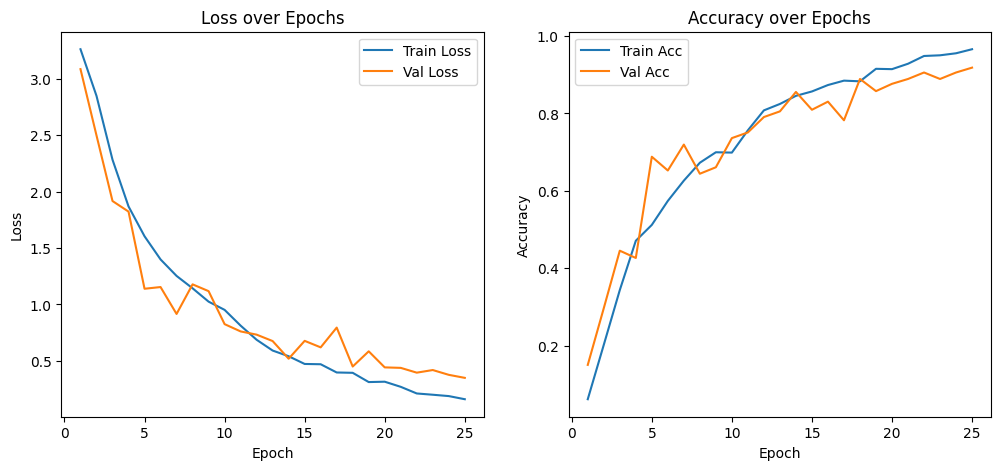

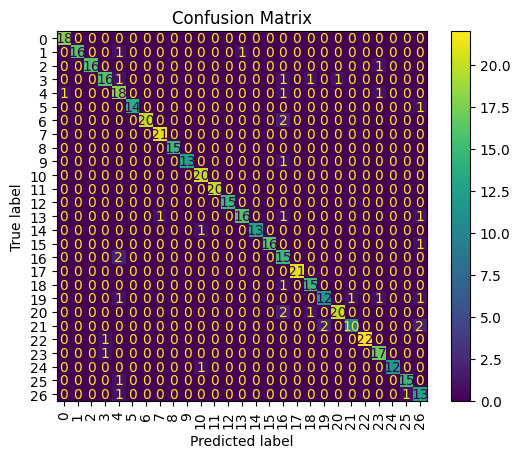


Najtrudniejsi autorzy:
21 - Acc: 0.7143
19 - Acc: 0.7500
3 - Acc: 0.8000
13 - Acc: 0.8421
4 - Acc: 0.8571

Najłatwiejsi autorzy:
17 - Acc: 1.0000
12 - Acc: 1.0000
11 - Acc: 1.0000
8 - Acc: 1.0000
0 - Acc: 1.0000


array([1.        , 0.88888889, 0.94117647, 0.8       , 0.85714286,
       0.93333333, 0.90909091, 1.        , 1.        , 0.92857143,
       1.        , 1.        , 1.        , 0.84210526, 0.92857143,
       0.94117647, 0.88235294, 1.        , 0.9375    , 0.75      ,
       0.86956522, 0.71428571, 0.95652174, 0.94444444, 0.92307692,
       0.9375    , 0.86666667])

In [27]:
plot_history(history_27)
classes_27 = sorted(list(set(val_labels_27)))
plot_confusion(val_labels_27, val_preds_27, classes_27)
author_difficulty(val_labels_27, val_preds_27, classes_27)